# Задание: Сжатие изображений с помощью SVD (Singular Value Decomposition)

## 1. Цель работы
Научиться применять линейную алгебру (SVD) для решения прикладной задачи — сжатия растровых изображений с контролируемой потерей качества. Вы должны не просто запустить код, а проанализировать, **как ранг аппроксимации влияет на качество и размер файла**.

## 2. Теоретическая справка (кратко)
Любую матрицу $ A $ размером $ m \times n $ можно разложить на три матрицы:
\[
A = U \cdot \Sigma \cdot V^T
\]
Где:
- $ U $ — ортогональная матрица размера $ m \times m $ (левые сингулярные векторы).
- $ \Sigma $ — диагональная матрица размера $ m \times n $, на диагонали которой стоят сингулярные числа $ \sigma_1 \ge \sigma_2 \ge ... \ge \sigma_k $.
- $ V^T $ — ортогональная матрица размера $ n \times n $ (правые сингулярные векторы).

**Идея сжатия:** Если оставить только первые $ r $ сингулярных чисел (и соответствующие столбцы U и V), мы получим матрицу $ A_r $, которая является наилучшим приближением $ A $ среди всех матриц ранга $ r $ (в смысле нормы Фробениуса).

## 3. Техническое задание (Пошаговый план)

### Часть А. Загрузка и подготовка данных (Базовый уровень)
1. **Выбор изображения:**
   - Загрузите любую картинку (можно стандартный `lena` или `peppers`, либо свою фотографию).
   - *Усложнение:* Картинка должна быть цветной, размером не менее 300x300 пикселей.
2. **Чтение файла:**
   - Используйте `PIL.Image.open()` или `matplotlib.image.imread()`.
3. **Преобразование в массив:**
   - Переведите картинку в формат `numpy.ndarray`.
4. **Работа с цветом (выбор стратегии):**
   - *Вариант А (простой):* Переведите изображение в градации серого (одноканальное) с помощью `.convert('L')` или формулы `Gray = 0.299*R + 0.587*G + 0.114*B`. Тогда у вас будет одна матрица $ A $ размером $ height \times width $.
   - *Вариант Б (продвинутый):* Оставьте 3 цветовых канала (RGB). Примените SVD отдельно к матрице **каждого** канала (Red, Green, Blue). Затем соберите их обратно.

### Часть Б. Применение SVD и восстановление
1. **Разложение:**
   - Используйте функцию `np.linalg.svd(матрица, full_matrices=False)`.
   - *Внимание:* Параметр `full_matrices=False` важен для экономии памяти, иначе матрица $ U $ получится слишком большой.
2. **Сжатие (аппроксимация) для разных рангов:**
   - Восстановите изображение, используя только `r` сингулярных чисел.
   - Обязательные значения `r`: **[1, 5, 10, 30, 100, min(shape)]** (где последнее — полное восстановление без потерь).
   - Формула восстановления:
     \[
     A_{approx} = U[:, :r] \cdot diag(\Sigma[:r]) \cdot V[:r, :]^T
     \]
   - *Подсказка:* `np.diag(s[:r])` создаст диагональную матрицу, но для ускорения лучше использовать `(U[:, :r] * s[:r]) @ V[:r, :]`.

### Часть В. Визуализация результатов
- Создайте один большой график (subplot) размером 2x3 или 3x2.
- На каждом подграфике отобразите восстановленное изображение.
- **Подпишите** каждый подграфик строкой: `"Ранг = r, Сжатие в X раз"`.
- Оригинальное изображение выведите отдельно (или как самый последний график).

### Часть Г. Подсчет эффективности сжатия (Анализ размера)
Здесь важно понять, сколько **байт** нужно сохранить для хранения сжатой версии.
- Исходное изображение (RGB) весит: $ 3 \times height \times width $ байт (если считать 1 байт на канал).
- Сжатая версия хранится в виде трех матриц: $ U_r $, $ \Sigma_r $, $ V^T_r $.
- Размер хранения:
  - $ U_r $: $ height \times r $ чисел.
  - $ \Sigma_r $: $ r $ чисел (диагональ).
  - $ V^T_r $: $ r \times width $ чисел.
- **Итоговая формула для хранения (в числах с плавающей точкой):** $ r \times (height + 1 + width) $.
  - *Для цветной картинки:* умножьте это на 3 (по количеству каналов).
- **Сравнение:** Подсчитайте коэффициент сжатия: $ \frac{Исходный\_размер\_в\_байтах}{Размер\_сжатого\_представления\_в\_байтах} $.
  - *Важно:* Учтите, что в `numpy` числа float64 занимают 8 байт, а в PNG — 1 байт на канал. Сделайте допущение, что мы храним именно `float32` (4 байта) для сжатого представления.

---

## 4. Обязательная часть: Автоматическая проверка (Self-Check)

Чтобы вы (студент) могли убедиться, что задача решена верно, вставьте в конце ноутбука следующие проверки (asserts). **Преподаватель будет смотреть на прохождение этих проверок.**

```python
# ---------- БЛОК АВТОПРОВЕРКИ (НЕ РЕДАКТИРОВАТЬ) ----------
# Предполагается, что у вас есть переменные:
# original_shape = (h, w, c) или (h, w)
# list_of_ranks = [1, 5, 10, 30, 100, ...]
# approximations = список восстановленных массивов (numpy) для каждого ранга

# 1. Проверка размерностей
for i, r in enumerate(list_of_ranks):
    assert approximations[i].shape == original_shape, f"Ошибка: размерность для ранга {r} не совпадает с исходной"

# 2. Проверка, что значения не выходят за пределы 0-255 (для RGB/серого)
for i, r in enumerate(list_of_ranks):
    arr = approximations[i]
    if arr.dtype != np.uint8:
        arr = np.clip(arr, 0, 255) # Если float, то проверяем диапазон
    assert arr.max() <= 255.1, f"Значения превышают 255 для ранга {r}"
    assert arr.min() >= -0.1, f"Значения меньше 0 для ранга {r}"

# 3. Проверка, что с ростом ранга ошибка уменьшается (метрика MSE)
from sklearn.metrics import mean_squared_error
mse_list = []
for i in range(len(approximations)):
    # Если цветная, считаем MSE по всем каналам
    mse = mean_squared_error(original_flat, approximations[i].flatten())
    mse_list.append(mse)

# Проверяем монотонность (MSE должен падать, так как мы добавляем сингулярные числа)
for i in range(1, len(mse_list)):
    assert mse_list[i] <= mse_list[i-1] + 1e-6, f"MSE не уменьшается между рангами {list_of_ranks[i-1]} и {list_of_ranks[i]}"

print("✅ Все автоматические проверки пройдены. Задание выполнено корректно!")
```

---

## 5. Критерии оценки (Для преподавателя)

*Максимум: 10 баллов.*

1. **Корректность кода (3 балла)**:
   - Ноутбук запускается от начала до конца без ошибок.
   - Все блоки автопроверки (Assertions) проходят успешно.
2. **Качество визуализации (2 балла)**:
   - Выведены все 6 графиков с подписями.
   - Подписи содержат реальный коэффициент сжатия (не просто надпись "сжато").
3. **Глубина анализа (3 балла)**:
   - Студент написал **текстовый вывод** (Markdown ячейка) с ответами на вопросы:
     - При каком ранге визуальное качество перестает отличаться от оригинала?
     - Для какого ранга достигается сжатие в 10 раз?
     - Почему для темных/светлых участков ошибка разная?
4. **Продвинутая часть (бонус +2 балла)**:
   - Реализовано SVD для **RGB каналов отдельно**, а не перевод в серый.
   - Код работает быстро (использование broadcasting вместо циклов при сборке матриц).

---

## 6. Полезные функции и библиотеки (шпаргалка)

```python
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import mean_squared_error

# Чтение
img = Image.open('my_pic.jpg')
img_gray = img.convert('L')  # Серый
img_array = np.array(img_gray) # или np.array(img) для RGB

# SVD
U, s, Vt = np.linalg.svd(matrix, full_matrices=False)

# Восстановление для ранга r
U_r = U[:, :r]
S_r = np.diag(s[:r])
Vt_r = Vt[:r, :]
reconstructed = U_r @ S_r @ Vt_r

# Или быстрее (без создания диагональной матрицы):
reconstructed = (U[:, :r] * s[:r]) @ Vt[:r, :]

# Визуализация
plt.imshow(reconstructed, cmap='gray') # для серого
plt.imshow(reconstructed.astype(np.uint8)) # для RGB (привести к целым)
plt.axis('off')
plt.show()
```

---

### Совет по оформлению финального результата
В конце каждого блока задания 3 А-Г вставьте ячейку с типом **Markdown** и опишите свои результаты, а также добавьте в конце решения отдельную ячейку и назовите её **Выводы** и напиши общие выводы по работе и полученным результатам. Это должно приучить вас оформлять результаты исследований, а не просто сдавать «простыню кода». Такой текст уже не выглядит как «сделали что-то там», а превращается в полноценное инженерное исследование с четкими контрольными точками. Успехов!

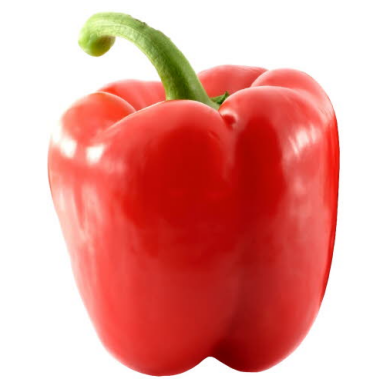

In [1]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
img = Image.open("1.png")

arr = np.array(img)
plt.imshow(arr.astype(np.uint8))
plt.axis('off')
plt.show()

Часть А. Загрузка и подготовка данных. Я загрузила изображение, прочитала его с помощью команды Image.open() из библиотеки PIL и преобразовала в формат numpy массива с помощью команды np.array из библиотеки numpy. Для работы я выбрала цветную картинку 480*480 и вариант Б. 

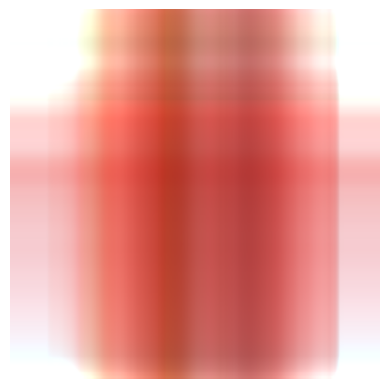

In [2]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
img = Image.open("1.png")
arr = np.array(img)
U_r, s_r, Vt_r = [], [], []
for channel in range(3):
    channel_data = arr[:, :, channel]
    U, s, Vt = np.linalg.svd(channel_data, full_matrices=False)
    U_r.append(U[:, :1])
    s_r.append(s[:1])
    Vt_r.append(Vt[:1, :])

reconstructed_channels = []
for channel in range(3):
    u1 = U_r[channel] 
    s1 = s_r[channel] 
    vt1 = Vt_r[channel]  

    reconstructed_channel = (u1 * s1) @ vt1
    reconstructed_channels.append(reconstructed_channel)

reconstructed = np.stack(reconstructed_channels, axis=2)

reconstructed = np.clip(reconstructed, 0, 255)

plt.imshow(reconstructed.astype(np.uint8))
plt.axis('off')
plt.show()

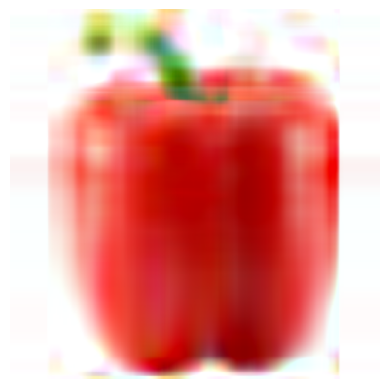

In [3]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
img = Image.open("1.png")
arr = np.array(img)
U_r, s_r, Vt_r = [], [], []
for channel in range(3):
    channel_data = arr[:, :, channel]
    U, s, Vt = np.linalg.svd(channel_data, full_matrices=False)
    U_r.append(U[:, :5])
    s_r.append(s[:5])
    Vt_r.append(Vt[:5, :])

reconstructed_channels = []
for channel in range(3):
    u1 = U_r[channel] 
    s1 = s_r[channel] 
    vt1 = Vt_r[channel]  

    reconstructed_channel = (u1 * s1) @ vt1
    reconstructed_channels.append(reconstructed_channel)

reconstructed = np.stack(reconstructed_channels, axis=2)

reconstructed = np.clip(reconstructed, 0, 255)

plt.imshow(reconstructed.astype(np.uint8))
plt.axis('off')
plt.show()

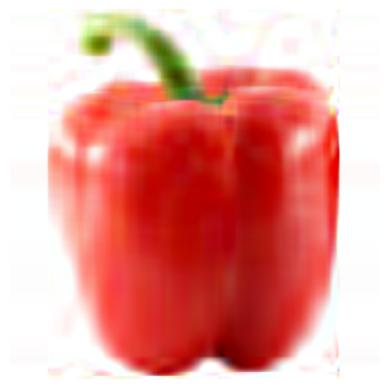

In [4]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
img = Image.open("1.png")
arr = np.array(img)
U_r, s_r, Vt_r = [], [], []
for channel in range(3):
    channel_data = arr[:, :, channel]
    U, s, Vt = np.linalg.svd(channel_data, full_matrices=False)
    U_r.append(U[:, :10])
    s_r.append(s[:10])
    Vt_r.append(Vt[:10, :])

reconstructed_channels = []
for channel in range(3):
    u1 = U_r[channel] 
    s1 = s_r[channel] 
    vt1 = Vt_r[channel]  

    reconstructed_channel = (u1 * s1) @ vt1
    reconstructed_channels.append(reconstructed_channel)

reconstructed = np.stack(reconstructed_channels, axis=2)

reconstructed = np.clip(reconstructed, 0, 255)

plt.imshow(reconstructed.astype(np.uint8))
plt.axis('off')
plt.show()

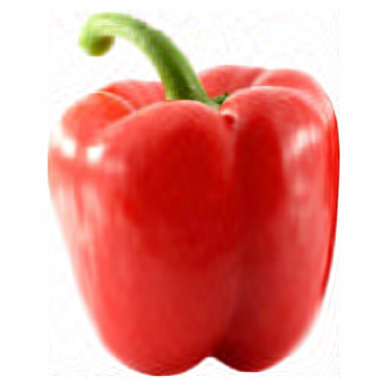

In [5]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
img = Image.open("1.png")
arr = np.array(img)
U_r, s_r, Vt_r = [], [], []
for channel in range(3):
    channel_data = arr[:, :, channel]
    U, s, Vt = np.linalg.svd(channel_data, full_matrices=False)
    U_r.append(U[:, :30])
    s_r.append(s[:30])
    Vt_r.append(Vt[:30, :])

reconstructed_channels = []
for channel in range(3):
    u1 = U_r[channel] 
    s1 = s_r[channel] 
    vt1 = Vt_r[channel]  

    reconstructed_channel = (u1 * s1) @ vt1
    reconstructed_channels.append(reconstructed_channel)

reconstructed = np.stack(reconstructed_channels, axis=2)

reconstructed = np.clip(reconstructed, 0, 255)

plt.imshow(reconstructed.astype(np.uint8))
plt.axis('off')
plt.show()

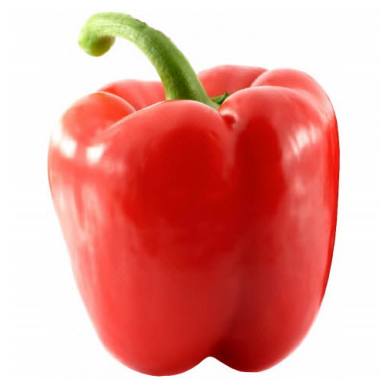

In [6]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
img = Image.open("1.png")
arr = np.array(img)
U_r, s_r, Vt_r = [], [], []
for channel in range(3):
    channel_data = arr[:, :, channel]
    U, s, Vt = np.linalg.svd(channel_data, full_matrices=False)
    U_r.append(U[:, :100])
    s_r.append(s[:100])
    Vt_r.append(Vt[:100, :])

reconstructed_channels = []
for channel in range(3):
    u1 = U_r[channel] 
    s1 = s_r[channel] 
    vt1 = Vt_r[channel]  

    reconstructed_channel = (u1 * s1) @ vt1
    reconstructed_channels.append(reconstructed_channel)

reconstructed = np.stack(reconstructed_channels, axis=2)

reconstructed = np.clip(reconstructed, 0, 255)

plt.imshow(reconstructed.astype(np.uint8))
plt.axis('off')
plt.show()

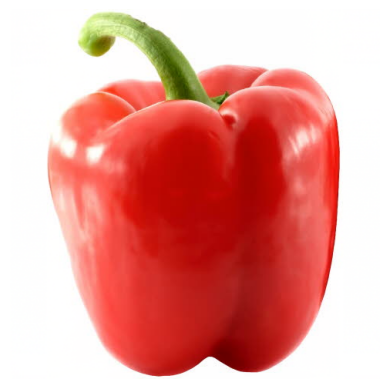

In [7]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
img = Image.open("1.png")
arr = np.array(img)
U_r, s_r, Vt_r = [], [], []
h,w,rgb=arr.shape
k=min(h,w)
for channel in range(3):
    channel_data = arr[:, :, channel]
    U, s, Vt = np.linalg.svd(channel_data, full_matrices=False)
    U_r.append(U[:, :k])
    s_r.append(s[:k])
    Vt_r.append(Vt[:k, :])

reconstructed_channels = []
for channel in range(3):
    u1 = U_r[channel] 
    s1 = s_r[channel] 
    vt1 = Vt_r[channel]  

    reconstructed_channel = (u1 * s1) @ vt1
    reconstructed_channels.append(reconstructed_channel)

reconstructed = np.stack(reconstructed_channels, axis=2)

reconstructed = np.clip(reconstructed, 0, 255)

plt.imshow(reconstructed.astype(np.uint8))
plt.axis('off')
plt.show()

Часть Б. С помощью команды channel_data = arr[:, :, channel], я заполняю массив 480 * 480 * 1, если chanell 0, то красными, 1 - зелёными, 2 - синими. Затем с помощью SVD расскладываю матрицу на компоненты $U$, $Σ$ и $V^T$. Сжимаю для ранга 1,5,10,30,100,min(shape)=480 с помощью команд, где я добавляю из матрицы U только первые n столбцов в U_r, из ветора s первые n элементов, из матрицы $V^T$ первые n строк. Открываю новый цикл для реконструкции каждого канала, беру из U_r матрицу для текущего канала и помещаю в u1 и далее для других переменных. Далее по формуле $A_r$ = $U_r$ * $Σ_r$ * $V_r^T$, я умножаю каждый элемент u1 на s1, тоесть из матрицы (480, n) и вектора (n,1) получается (480,n), а затем матрично умножаю на vt1 (480,n) на (n,480) получаю (480,480). Добавляю восстановленный канал в список. Объединию 3 канала в одну картинку с помощью np.stack из библиотеки numpy, с axis=2 (добавляет количество входных массивов в матрицу) и в итоге получается (480,480,3). Обрезаю все значения с помощью np.clip, чтобы были в диапазоне [0,255], все числа меньше 0 становятся 0, Все числа больше 255 становятся 255.

(np.float64(-0.5), np.float64(479.5), np.float64(479.5), np.float64(-0.5))

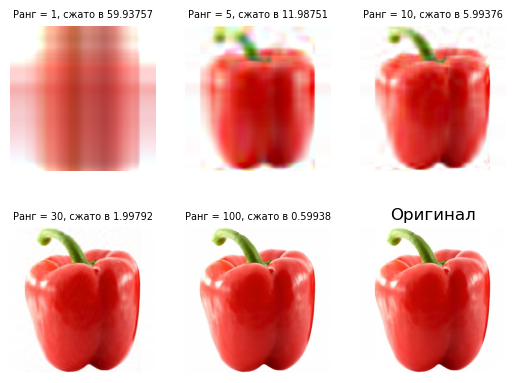

In [8]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
img = Image.open("1.png")
arr = np.array(img)
h,w,rgb=arr.shape
k=min(h,w)
U_r, s_r, Vt_r = [], [], []
r=[1,5,10,30,100,k]
for channel in range(3):
    channel_data = arr[:, :, channel]
    U, s, Vt = np.linalg.svd(channel_data, full_matrices=False)
    U_r.append(U[:, :r[0]])
    s_r.append(s[:r[0]])
    Vt_r.append(Vt[:r[0], :])

reconstructed_channels = []
for channel in range(3):
    u1 = U_r[channel] 
    s1 = s_r[channel] 
    vt1 = Vt_r[channel]  

    reconstructed_channel = (u1 * s1) @ vt1
    reconstructed_channels.append(reconstructed_channel)

reconstructed1 = np.stack(reconstructed_channels, axis=2)

reconstructed1 = np.clip(reconstructed1, 0, 255)
U_r, s_r, Vt_r = [], [], []
for channel in range(3):
    channel_data = arr[:, :, channel]
    U, s, Vt = np.linalg.svd(channel_data, full_matrices=False)
    U_r.append(U[:, :r[1]])
    s_r.append(s[:r[1]])
    Vt_r.append(Vt[:r[1], :])

reconstructed_channels = []
for channel in range(3):
    u1 = U_r[channel] 
    s1 = s_r[channel] 
    vt1 = Vt_r[channel]  

    reconstructed_channel = (u1 * s1) @ vt1
    reconstructed_channels.append(reconstructed_channel)

reconstructed5 = np.stack(reconstructed_channels, axis=2)

reconstructed5 = np.clip(reconstructed5, 0, 255)
U_r, s_r, Vt_r = [], [], []
for channel in range(3):
    channel_data = arr[:, :, channel]
    U, s, Vt = np.linalg.svd(channel_data, full_matrices=False)
    U_r.append(U[:, :r[2]])
    s_r.append(s[:r[2]])
    Vt_r.append(Vt[:r[2], :])

reconstructed_channels = []
for channel in range(3):
    u1 = U_r[channel] 
    s1 = s_r[channel] 
    vt1 = Vt_r[channel]  

    reconstructed_channel = (u1 * s1) @ vt1
    reconstructed_channels.append(reconstructed_channel)

reconstructed10 = np.stack(reconstructed_channels, axis=2)

reconstructed10 = np.clip(reconstructed10, 0, 255)
U_r, s_r, Vt_r = [], [], []
for channel in range(3):
    channel_data = arr[:, :, channel]
    U, s, Vt = np.linalg.svd(channel_data, full_matrices=False)
    U_r.append(U[:, :r[3]])
    s_r.append(s[:r[3]])
    Vt_r.append(Vt[:r[3], :])

reconstructed_channels = []
for channel in range(3):
    u1 = U_r[channel] 
    s1 = s_r[channel] 
    vt1 = Vt_r[channel]  

    reconstructed_channel = (u1 * s1) @ vt1
    reconstructed_channels.append(reconstructed_channel)

reconstructed30 = np.stack(reconstructed_channels, axis=2)

reconstructed30 = np.clip(reconstructed30, 0, 255)
U_r, s_r, Vt_r = [], [], []
for channel in range(3):
    channel_data = arr[:, :, channel]
    U, s, Vt = np.linalg.svd(channel_data, full_matrices=False)
    U_r.append(U[:, :r[4]])
    s_r.append(s[:r[4]])
    Vt_r.append(Vt[:r[4], :])

reconstructed_channels = []
for channel in range(3):
    u1 = U_r[channel] 
    s1 = s_r[channel] 
    vt1 = Vt_r[channel]  

    reconstructed_channel = (u1 * s1) @ vt1
    reconstructed_channels.append(reconstructed_channel)

reconstructed100 = np.stack(reconstructed_channels, axis=2)

reconstructed100 = np.clip(reconstructed100, 0, 255)
U_r, s_r, Vt_r = [], [], []
for channel in range(3):
    channel_data = arr[:, :, channel]
    U, s, Vt = np.linalg.svd(channel_data, full_matrices=False)
    U_r.append(U[:, :r[5]])
    s_r.append(s[:r[5]])
    Vt_r.append(Vt[:r[5], :])

reconstructed_channels = []
for channel in range(3):
    u1 = U_r[channel] 
    s1 = s_r[channel] 
    vt1 = Vt_r[channel]  

    reconstructed_channel = (u1 * s1) @ vt1
    reconstructed_channels.append(reconstructed_channel)

reconstructedk = np.stack(reconstructed_channels, axis=2)

reconstructedk = np.clip(reconstructedk, 0, 255)
ves_orig=3*h*w
ves1 = r[0] * 3 * (h + 1 + w) * 4
ves5 = r[1] * 3 * (h + 1 + w) * 4
ves10 = r[2] * 3 * (h + 1 + w) * 4
ves30 = r[3] * 3 * (h + 1 + w) * 4
ves100 = r[4] * 3 * (h + 1 + w) * 4
vesk = r[5] * 3 * (h + 1 + w) * 4
plt.subplot(2, 3, 1)
plt.imshow(reconstructed1.astype(np.uint8))
plt.title(f"Ранг = {r[0]}, сжато в {round(ves_orig/ves1, 5)}", fontsize=7)
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(reconstructed5.astype(np.uint8))
plt.title(f"Ранг = {r[1]}, сжато в {round(ves_orig/ves5, 5)}", fontsize=7)
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(reconstructed10.astype(np.uint8))
plt.title(f"Ранг = {r[2]}, сжато в {round(ves_orig/ves10, 5)}", fontsize=7)
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(reconstructed30.astype(np.uint8))
plt.title(f"Ранг = {r[3]}, сжато в {round(ves_orig/ves30, 5)}", fontsize=7)
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(reconstructed100.astype(np.uint8))
plt.title(f"Ранг = {r[4]}, сжато в {round(ves_orig/ves100, 5)}", fontsize=7)
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(reconstructedk.astype(np.uint8))
plt.title('Оригинал')
plt.axis('off')

Часть В. Визуализация результатов. Я построила график 2×3 с восстановленными изображениями для рангов [1,5,10,30,100] и оригиналом. Визуально видно, что с ростом ранга качество улучшается: при r=1 изображение сильно размыто, при r=10 появляются контуры перца, при r=30 и r=100 качество близко к оригиналу.

In [9]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
img = Image.open("1.png")
arr = np.array(img)
h,w,rgb=arr.shape
k=min(h,w)
r = [1, 5, 10, 30, 100, k]
s_o = h * w * 3  

for i in r:
    s = i * (h + 1 + w) * 4 * 3
    k = s_o / s
    if i==r[5]:
        print(f"{i:<10} {s:<10}", 'Оригинал')
    else:
        print(f"{i:<10} {s:<10} {k:<10}")

1          11532      59.937565036420395
5          57660      11.987513007284079
10         115320     5.9937565036420395
30         345960     1.9979188345473464
100        1153200    0.5993756503642039
480        5535360    Оригинал


Часть Г. Эффективность сжатия. Максимально приближенное качество картинки достигнуто при ранге 100 и составило 0.6 раз. Но картинки почти неотличимы, но памяти картинка с рангом 100 занимает меньше.

In [10]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
approximations = []
img = Image.open("1.png")
arr = np.array(img)
h,w,rgb=arr.shape
k=min(h,w)
r = [1, 5, 10, 30, 100, k]
original_flat = arr.flatten()
original_shape = arr.shape
list_of_ranks = r
U_r, s_r, Vt_r = [], [], []
for channel in range(3):
    channel_data = arr[:, :, channel]
    U, s, Vt = np.linalg.svd(channel_data, full_matrices=False)
    U_r.append(U[:, :r[0]])
    s_r.append(s[:r[0]])
    Vt_r.append(Vt[:r[0], :])

reconstructed_channels = []
for channel in range(3):
    u1 = U_r[channel] 
    s1 = s_r[channel] 
    vt1 = Vt_r[channel]  

    reconstructed_channel = (u1 * s1) @ vt1
    reconstructed_channels.append(reconstructed_channel)

reconstructed1 = np.stack(reconstructed_channels, axis=2)

reconstructed1 = np.clip(reconstructed1, 0, 255)
U_r, s_r, Vt_r = [], [], []
for channel in range(3):
    channel_data = arr[:, :, channel]
    U, s, Vt = np.linalg.svd(channel_data, full_matrices=False)
    U_r.append(U[:, :r[1]])
    s_r.append(s[:r[1]])
    Vt_r.append(Vt[:r[1], :])

reconstructed_channels = []
for channel in range(3):
    u1 = U_r[channel] 
    s1 = s_r[channel] 
    vt1 = Vt_r[channel]  

    reconstructed_channel = (u1 * s1) @ vt1
    reconstructed_channels.append(reconstructed_channel)

reconstructed5 = np.stack(reconstructed_channels, axis=2)

reconstructed5 = np.clip(reconstructed5, 0, 255)
U_r, s_r, Vt_r = [], [], []
for channel in range(3):
    channel_data = arr[:, :, channel]
    U, s, Vt = np.linalg.svd(channel_data, full_matrices=False)
    U_r.append(U[:, :r[2]])
    s_r.append(s[:r[2]])
    Vt_r.append(Vt[:r[2], :])

reconstructed_channels = []
for channel in range(3):
    u1 = U_r[channel] 
    s1 = s_r[channel] 
    vt1 = Vt_r[channel]  

    reconstructed_channel = (u1 * s1) @ vt1
    reconstructed_channels.append(reconstructed_channel)

reconstructed10 = np.stack(reconstructed_channels, axis=2)

reconstructed10 = np.clip(reconstructed10, 0, 255)
U_r, s_r, Vt_r = [], [], []
for channel in range(3):
    channel_data = arr[:, :, channel]
    U, s, Vt = np.linalg.svd(channel_data, full_matrices=False)
    U_r.append(U[:, :r[3]])
    s_r.append(s[:r[3]])
    Vt_r.append(Vt[:r[3], :])

reconstructed_channels = []
for channel in range(3):
    u1 = U_r[channel] 
    s1 = s_r[channel] 
    vt1 = Vt_r[channel]  

    reconstructed_channel = (u1 * s1) @ vt1
    reconstructed_channels.append(reconstructed_channel)

reconstructed30 = np.stack(reconstructed_channels, axis=2)

reconstructed30 = np.clip(reconstructed30, 0, 255)
U_r, s_r, Vt_r = [], [], []
for channel in range(3):
    channel_data = arr[:, :, channel]
    U, s, Vt = np.linalg.svd(channel_data, full_matrices=False)
    U_r.append(U[:, :r[4]])
    s_r.append(s[:r[4]])
    Vt_r.append(Vt[:r[4], :])

reconstructed_channels = []
for channel in range(3):
    u1 = U_r[channel] 
    s1 = s_r[channel] 
    vt1 = Vt_r[channel]  

    reconstructed_channel = (u1 * s1) @ vt1
    reconstructed_channels.append(reconstructed_channel)

reconstructed100 = np.stack(reconstructed_channels, axis=2)

reconstructed100 = np.clip(reconstructed100, 0, 255)
U_r, s_r, Vt_r = [], [], []
for channel in range(3):
    channel_data = arr[:, :, channel]
    U, s, Vt = np.linalg.svd(channel_data, full_matrices=False)
    U_r.append(U[:, :r[5]])
    s_r.append(s[:r[5]])
    Vt_r.append(Vt[:r[5], :])

reconstructed_channels = []
for channel in range(3):
    u1 = U_r[channel] 
    s1 = s_r[channel] 
    vt1 = Vt_r[channel]  

    reconstructed_channel = (u1 * s1) @ vt1
    reconstructed_channels.append(reconstructed_channel)

reconstructedk = np.stack(reconstructed_channels, axis=2)

reconstructedk = np.clip(reconstructedk, 0, 255)
approximations.append(reconstructed1)
approximations.append(reconstructed5)
approximations.append(reconstructed10)
approximations.append(reconstructed30)
approximations.append(reconstructed100)
approximations.append(reconstructedk)
for i, r in enumerate(list_of_ranks):
    assert approximations[i].shape == original_shape, f"Ошибка: размерность для ранга {r} не совпадает с исходной"

# 2. Проверка, что значения не выходят за пределы 0-255 (для RGB/серого)
for i, r in enumerate(list_of_ranks):
    arr = approximations[i]
    if arr.dtype != np.uint8:
        arr = np.clip(arr, 0, 255) # Если float, то проверяем диапазон
    assert arr.max() <= 255.1, f"Значения превышают 255 для ранга {r}"
    assert arr.min() >= -0.1, f"Значения меньше 0 для ранга {r}"

# 3. Проверка, что с ростом ранга ошибка уменьшается (метрика MSE)
from sklearn.metrics import mean_squared_error
mse_list = []
for i in range(len(approximations)):
    # Если цветная, считаем MSE по всем каналам
    mse = mean_squared_error(original_flat, approximations[i].flatten())
    mse_list.append(mse)

# Проверяем монотонность (MSE должен падать, так как мы добавляем сингулярные числа)
for i in range(1, len(mse_list)):
    assert mse_list[i] <= mse_list[i-1] + 1e-6, f"MSE не уменьшается между рангами {list_of_ranks[i-1]} и {list_of_ranks[i]}"

print("✅ Все автоматические проверки пройдены. Задание выполнено корректно!")

✅ Все автоматические проверки пройдены. Задание выполнено корректно!
